##  Step: Generate Prediction Probabilities for ROC-AUC Evaluation

In this step, we are generating the predicted probabilities (`y_proba`) for the "Yes" class for each of our three models:

1. Has a high blood pressure  
2. Has diabetes  
3. Cardiovascular condition (Heart disease or stroke)

We save these predictions into CSV files to:
- Plot ROC-AUC curves later
- Compare model discrimination power
- Visualize true vs predicted probabilities

>  NOTE: Since we saved each model as a `Pipeline` (preprocessor + classifier), we do **not** manually preprocess the input — the model handles it internally.


###  Step: Generate Prediction Probabilities for ROC-AUC

In this step, we use our trained logistic regression pipelines to generate **probability predictions** on the full held-out dataset (not undersampled). This is necessary to evaluate model performance using **ROC-AUC**.

- We use `predict_proba()` to get probabilities for the `"Yes"` class.
- We store both the true label and predicted probability in a CSV file.
- These files will be used in the next step for ROC curve and threshold tuning.

This ensures we evaluate our models fairly and consistently on real-world distributions.


In [3]:
import os
import pandas as pd

# --- Path Config ---
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
STATS_DIR = os.path.join(OUTPUTS_DIR, "statistics")
PLOTS_DIR = os.path.join(OUTPUTS_DIR, "plots")
METRICS_DIR = os.path.join(OUTPUTS_DIR, "metrics")

# Make sure subfolders exist
os.makedirs(STATS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

part16_stats_dir = os.path.join(STATS_DIR, "part16_roc_auc")
os.makedirs(part16_stats_dir, exist_ok=True)

part16_plots_dir = os.path.join(PLOTS_DIR, "part16_roc_auc")
os.makedirs(part16_plots_dir, exist_ok=True)

# === Directories for ROC outputs ===
part16_stats_dir = os.path.join(STATS_DIR, "part16_roc_auc")
os.makedirs(part16_stats_dir, exist_ok=True)

part16_plots_dir = os.path.join(PLOTS_DIR, "part16_roc_auc")
os.makedirs(part16_plots_dir, exist_ok=True)


In [2]:
import pandas as pd
import joblib


def generate_predictions(data_path, target_col, model_file, output_csv):
    """
    Generate probability predictions using trained model pipeline (with preprocessor inside)
    and save them to a CSV file with true and predicted labels.
    """
    # Load data and model
    df = pd.read_csv(data_path)
    
    # Optional: Remove unknowns in target
    df = df[df[target_col].isin(["Yes", "No"])]

    model = joblib.load(model_file)

    # Separate features and target
    X = df.drop(columns=[target_col])
    y = df[target_col].map({"No": 0, "Yes": 1})

    # Predict probabilities
    y_proba = model.predict_proba(X)[:, 1]

    # Save predictions
    pred_df = pd.DataFrame({
        'y_true': y,
        'y_proba': y_proba
    })
    pred_df.to_csv(output_csv, index=False)
    print(f" Saved predictions to {output_csv}")



#  Run for all 3 models 

# Model 1: High Blood Pressure
generate_predictions(
    data_path=os.path.join(STATS_DIR, "part14_final_models", "test_highbp.csv"),
    target_col="Has a high blood pressure",
    model_file=os.path.join(METRICS_DIR, "part14_final_models", "model_highbp.pkl"),
    output_csv=os.path.join(STATS_DIR, "part16_roc_auc", "predictions_highbp.csv")
)

# Model 2: Diabetes
generate_predictions(
    data_path=os.path.join(STATS_DIR, "part14_final_models", "test_diabetes.csv"),
    target_col="Has diabetes",
    model_file=os.path.join(METRICS_DIR, "part14_final_models", "model_diabetes.pkl"),
    output_csv=os.path.join(STATS_DIR, "part16_roc_auc", "predictions_diabetes.csv")
)

# Model 3: Cardiovascular
generate_predictions(
    data_path=os.path.join(STATS_DIR, "part14_final_models", "test_cardio.csv"),
    target_col="Cardiovascular condition (Heart disease or stroke)",
    model_file=os.path.join(METRICS_DIR, "part14_final_models", "model_cardio.pkl"),
    output_csv=os.path.join(STATS_DIR, "part16_roc_auc", "predictions_cardio.csv")
)


 Saved predictions to d:\Projects\health-risk-prediction\outputs\statistics\part16_roc_auc\predictions_highbp.csv
 Saved predictions to d:\Projects\health-risk-prediction\outputs\statistics\part16_roc_auc\predictions_diabetes.csv
 Saved predictions to d:\Projects\health-risk-prediction\outputs\statistics\part16_roc_auc\predictions_cardio.csv


#  Final Evaluation using ROC-AUC

In this final modeling step, we evaluate our trained **logistic regression models** for each target condition using the **ROC-AUC metric** (Receiver Operating Characteristic - Area Under Curve).

##  Why ROC-AUC?
- Logistic Regression outputs probabilities.
- ROC-AUC tells us how well the model separates the two classes (**Yes** vs **No**).
- Higher AUC → better model performance across all thresholds.

## What We'll Do
1. Load prediction files (`y_true`, `y_proba`) for all 3 models.
2. Plot ROC curves.
3. Display AUC scores.


###  Step: ROC-AUC Evaluation for All Models

In this step, we evaluate the performance of all three logistic regression models using the **ROC-AUC metric**. This metric is especially useful for imbalanced classification, as it assesses how well the model separates positive and negative classes across thresholds.

We:
- Use the predicted probabilities (`y_proba`) and true labels (`y_true`)
- Plot **ROC curves** for all models on the same graph
- Save the plot for visual reporting
- Print individual AUC scores to compare performance

This helps us **visually assess trade-offs** and identify strong-performing models.



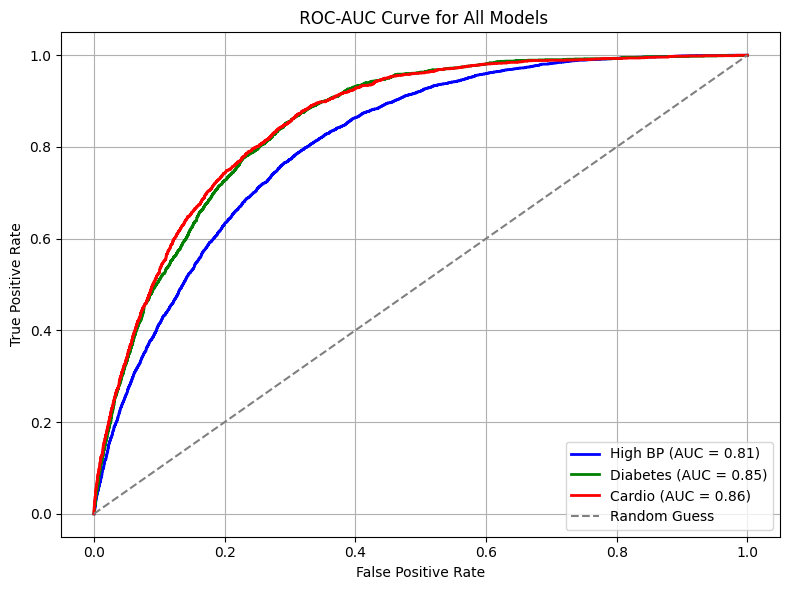

 AUC Scores:
 High Blood Pressure: 0.810
 Diabetes: 0.852
 Cardiovascular Condition: 0.856


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc

#  Helper function to plot ROC and return AUC
def plot_roc_auc(pred_csv, label, color, individual_plot_path=None):
    """
    Reads predictions from CSV, computes ROC curve, and returns AUC value.
    Optionally saves the individual ROC plot.
    """
    df = pd.read_csv(pred_csv)

    # Drop rows where target is missing (due to 'Unknown' during generation)
    df = df.dropna(subset=["y_true"])

    y_true = df["y_true"]
    y_proba = df["y_proba"]

    # Compute ROC
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    # Plot individual if requested
    if individual_plot_path:
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC = {roc_auc:.2f})")
        plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess")
        plt.title(f"ROC Curve - {label}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(individual_plot_path)
        plt.close()

    return fpr, tpr, roc_auc

# ===  Combined ROC-AUC Plot ===
plt.figure(figsize=(8, 6))

# Generate curves & individual plots
# Generate curves & individual plots
fpr_bp, tpr_bp, auc_bp = plot_roc_auc(
    os.path.join(part16_stats_dir, "predictions_highbp.csv"),
    "High BP", "blue",
    os.path.join(part16_plots_dir, "roc_highbp.png")
)

fpr_diabetes, tpr_diabetes, auc_diabetes = plot_roc_auc(
    os.path.join(part16_stats_dir, "predictions_diabetes.csv"),
    "Diabetes", "green",
    os.path.join(part16_plots_dir, "roc_diabetes.png")
)

fpr_cardio, tpr_cardio, auc_cardio = plot_roc_auc(
    os.path.join(part16_stats_dir, "predictions_cardio.csv"),
    "Cardio", "red",
    os.path.join(part16_plots_dir, "roc_cardio.png")
)

# Plot combined curves
plt.plot(fpr_bp, tpr_bp, color="blue", lw=2, label=f"High BP (AUC = {auc_bp:.2f})")
plt.plot(fpr_diabetes, tpr_diabetes, color="green", lw=2, label=f"Diabetes (AUC = {auc_diabetes:.2f})")
plt.plot(fpr_cardio, tpr_cardio, color="red", lw=2, label=f"Cardio (AUC = {auc_cardio:.2f})")

# Diagonal reference
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess")

# Final plot formatting
plt.title(" ROC-AUC Curve for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(part16_plots_dir, "roc_auc_all_models.png"))
plt.show()

# Print AUC Scores
print(" AUC Scores:")
print(f" High Blood Pressure: {auc_bp:.3f}")
print(f" Diabetes: {auc_diabetes:.3f}")
print(f" Cardiovascular Condition: {auc_cardio:.3f}")
